# M1A4 - Introdução a OpenCV

> **Resumo:** OpenCV é A biblioteca de visão computacional. Aqui aprendemos a ler imagens com `cv2.imread`, lidar com a diferença BGR vs RGB, e fazer transformações básicas. Imagem de teste: Knuckles 👊

**Estrutura do notebook:**

- Instalação e importação
- Ler imagens do disco
- Transformações de imagens
- Próximos passos
- ✅ Atividades Complementares (resolvidas)

## Instalação e Importação da Biblioteca

In [1]:
!pip install opencv-python

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

## Ler Imagens do Disco

OpenCV também lê imagens como arrays NumPy, mas com uma diferença importante: os canais vêm em **BGR** (não RGB).

Função: `cv2.imread`

In [3]:
image = cv2.imread("knuckles.jpg")

Mesma estrutura NumPy que vimos na aula anterior:

In [4]:
print(f"Tipo: {type(image)}")
print(f"Shape: {image.shape}")
print(f"Dtype: {image.dtype}")

Tipo: <class 'numpy.ndarray'>
Shape: (736, 736, 3)
Dtype: uint8


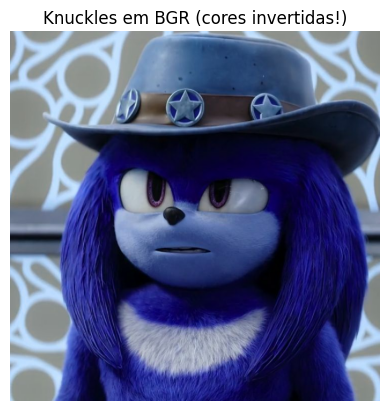

In [5]:
# Visualizando sem converter — cores ficam trocadas (BGR)
plt.imshow(image)
plt.title("Knuckles em BGR (cores invertidas!)")
plt.axis("off")
plt.show()

## Transformações de Imagens

Como as imagens são arrays NumPy, podemos aplicar operações matemáticas diretamente:

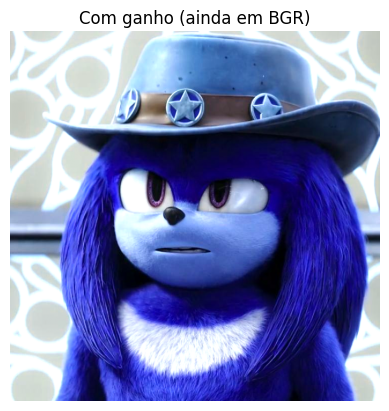

In [6]:
# Ajuste de brilho/ganho multiplicando os pixels (1.5 = +50% de brilho)
gain = np.clip(image / 255 * 1.5, 0, 1)
plt.imshow(gain)
plt.title("Com ganho (ainda em BGR)")
plt.axis("off")
plt.show()

**Convertendo BGR → RGB** para visualizar corretamente com matplotlib:

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128074 (\N{FISTED HAND SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


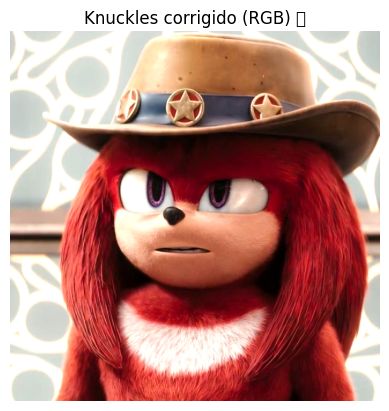

In [7]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gain_rgb = np.clip(image_rgb / 255 * 1.5, 0, 1)
plt.imshow(gain_rgb)
plt.title("Knuckles corrigido (RGB)")
plt.axis("off")
plt.show()

**Recorte (crop)** — fatiar o array como qualquer matriz NumPy:

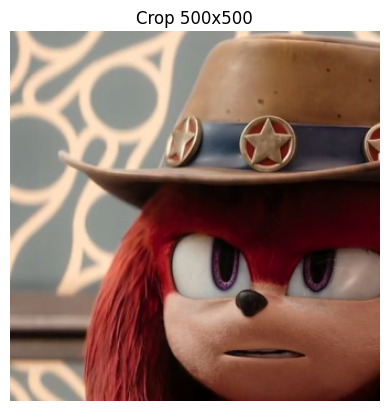

In [8]:
crop = image_rgb[0:500, 0:500]
plt.imshow(crop)
plt.title("Crop 500x500")
plt.axis("off")
plt.show()

**Resize** — OpenCV tem funções otimizadas:

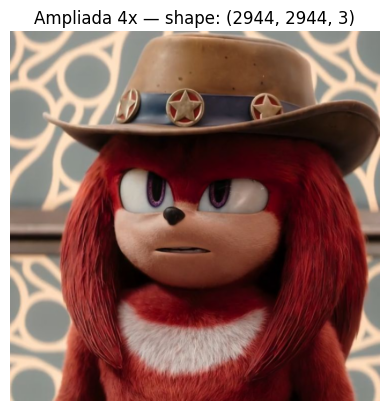

In [9]:
larger = cv2.resize(image_rgb, (int(image.shape[1] * 4), int(image.shape[0] * 4)))
plt.imshow(larger)
plt.title(f"Ampliada 4x — shape: {larger.shape}")
plt.axis("off")
plt.show()

## Próximos Passos e Referências

Nas próximas aulas vamos explorar mais operações do OpenCV: transformações geométricas, desenhos, e filtros.

**Referências úteis:**

- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## ✅ Atividades Complementares

### 1. Ler outra imagem e aplicar os mesmos comandos

Shape: (900, 1600, 3)
Dtype: uint8


/tmp/ipykernel_2789/1339790274.py:26: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


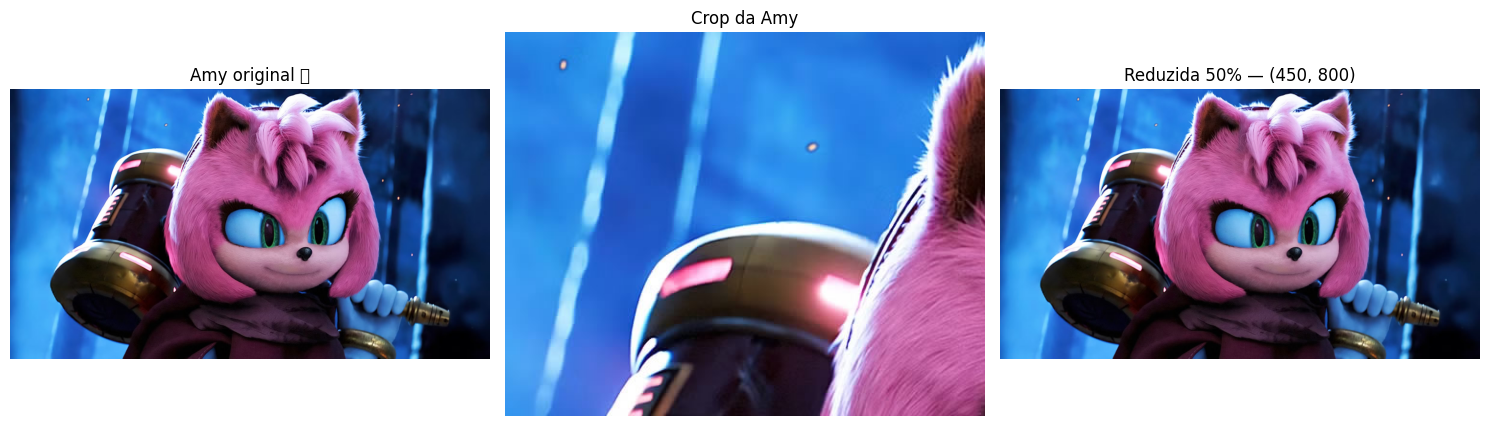

In [10]:
amy = cv2.imread("amy.jpg")
amy_rgb = cv2.cvtColor(amy, cv2.COLOR_BGR2RGB)

print(f"Shape: {amy_rgb.shape}")
print(f"Dtype: {amy_rgb.dtype}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original
axes[0].imshow(amy_rgb)
axes[0].set_title("Amy original")
axes[0].axis("off")

# Crop
crop_amy = amy_rgb[0:400, 200:700]
axes[1].imshow(crop_amy)
axes[1].set_title("Crop da Amy")
axes[1].axis("off")

# Resize menor
smaller_amy = cv2.resize(amy_rgb, (amy.shape[1] // 2, amy.shape[0] // 2))
axes[2].imshow(smaller_amy)
axes[2].set_title(f"Reduzida 50% — {smaller_amy.shape[:2]}")
axes[2].axis("off")

plt.tight_layout()
plt.show()